In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Load and Merge All Data
stops_df = pd.read_csv('../data/raw/stops.txt')
routes_df = pd.read_csv('../data/raw/routes.txt')
trips_df = pd.read_csv('../data/raw/trips.txt')
stop_times_df = pd.read_csv('../data/raw/stop_times.txt')

trip_route_df = pd.merge(trips_df, routes_df, on='route_id', how='left')
schedule_df = pd.merge(stop_times_df, trip_route_df, on='trip_id', how='left')
master_df = pd.merge(schedule_df, stops_df, on='stop_id', how='left')

# Save master_df to your processed data folder
master_df.to_csv('../data/processed/master_df.csv', index=False)

# Display the first few rows of our master scheduled timetable
master_df.head()



,trip_id,stop_sequence,stop_id,arrival_time,departure_time,timepoint,shape_dist_traveled,service_id,route_id,direction_id,...,route_color,route_text_color,route_sort_order,stop_name,stop_lat,stop_lon,zone_id,location_type,parent_station,platform_code
0,SA_101482,1,MGB3,06:00:00,06:00:00,1,647,SA,GREEN,0,...,009846,000000,2,Mahatma Gandhi Bus Station,17.379789,78.486157,MGB_G,0,MGB,3.0
1,SA_101482,2,SUB1,06:01:41,06:01:41,1,1424,SA,GREEN,0,...,009846,000000,2,Sultan Bazar,17.384447,78.484024,SUB,0,SUB,1.0
2,SA_101482,3,NAR1,06:03:37,06:03:37,1,2720,SA,GREEN,0,...,009846,000000,2,Narayanaguda,17.394366,78.489958,NAR,0,NAR,1.0
3,SA_101482,4,CDP1,06:05:23,06:05:23,1,3593,SA,GREEN,0,...,009846,000000,2,Chikkadpally,17.400363,78.494896,CDP,0,CDP,1.0
4,SA_101482,5,RTC1,06:06:51,06:06:51,1,4363,SA,GREEN,0,...,009846,000000,2,RTC Cross Roads,17.407032,78.496802,RTC,0,RTC,1.0


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# 2. Network-Wide Route Breakdown
print("Total Scheduled Stops by Route:")
print(master_df['route_short_name'].value_counts())


# Check the exact names of the routes in the dataset
print("Available Routes:")
print(master_df['route_short_name'].unique())




Total Scheduled Stops by Route:
route_short_name
C1_RED      30648
C3_BLUE     25678
C2_GREEN     4711
Name: count, dtype: int64
Available Routes:
<ArrowStringArray>
['C2_GREEN', 'C1_RED', 'C3_BLUE']
Length: 3, dtype: str


Top 5 Busiest Stations:
                 Station Name  Scheduled Stops
0                    Ameerpet             2265
1  Mahatma Gandhi Bus Station             1661
2               Dilsukh Nagar             1136
3               Chaitanyapuri             1136
4           Victoria Memorial             1136


C:\Users\Ahana Banerjee\AppData\Local\Temp\ipykernel_15948\3038016039.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=busiest_stations.head(10), x='Scheduled Stops', y='Station Name', palette='viridis')


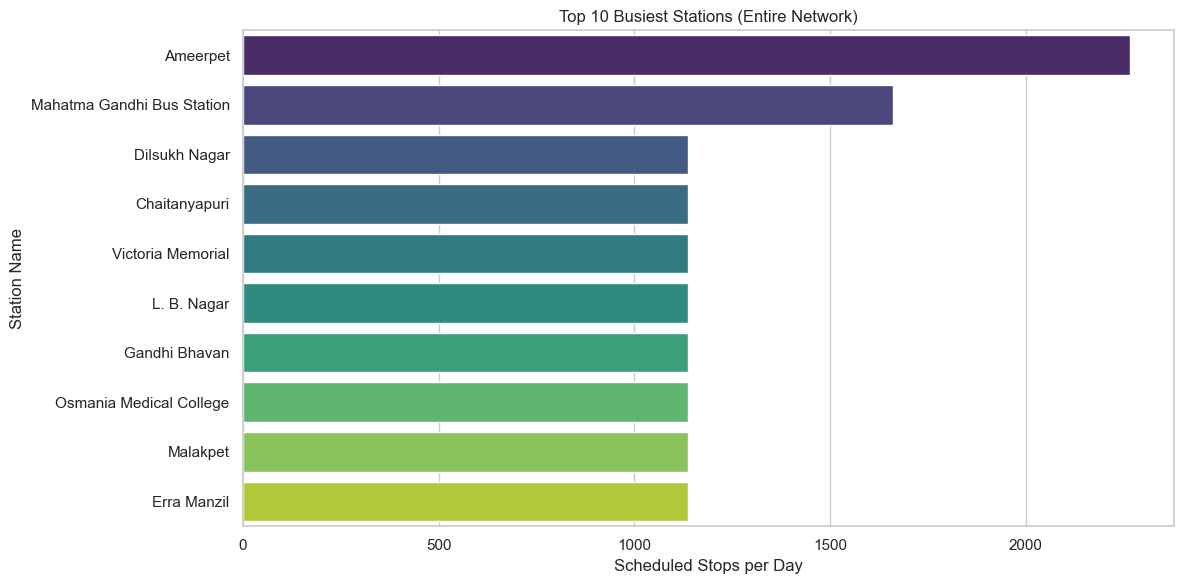

In [3]:
# 3. Network-Wide Busiest Stations
busiest_stations = master_df['stop_name'].value_counts().reset_index()
busiest_stations.columns = ['Station Name', 'Scheduled Stops']

print("Top 5 Busiest Stations:")
print(busiest_stations.head())

plt.figure(figsize=(12, 6))
sns.barplot(data=busiest_stations.head(10), x='Scheduled Stops', y='Station Name', palette='viridis')
plt.title('Top 10 Busiest Stations (Entire Network)')
plt.xlabel('Scheduled Stops per Day')
plt.ylabel('Station Name')
plt.tight_layout()
plt.show()



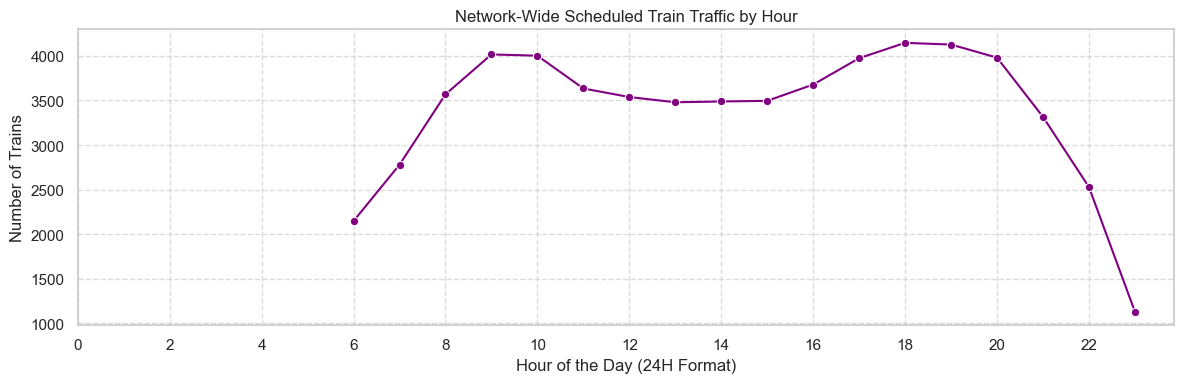

In [4]:
# 4. Network-Wide Peak Hours
master_df['hour'] = master_df['arrival_time'].str.split(':').str[0].astype(int) % 24
hourly_traffic = master_df['hour'].value_counts().sort_index().reset_index()
hourly_traffic.columns = ['Hour of Day', 'Number of Trains Scheduled']

plt.figure(figsize=(12, 4))
sns.lineplot(data=hourly_traffic, x='Hour of Day', y='Number of Trains Scheduled', marker='o', color='purple')
plt.title('Network-Wide Scheduled Train Traffic by Hour')
plt.xlabel('Hour of the Day (24H Format)')
plt.ylabel('Number of Trains')
plt.xticks(range(0, 24, 2))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [5]:
import folium

# 1. Extract unique stations and their exact coordinates for the Red Line
# We group by station name and take the first available latitude and longitude
station_coords = master_df.groupby('stop_name')[['stop_lat', 'stop_lon']].first().reset_index()

# 2. Find the geographic center of our map to set the initial view
center_lat = station_coords['stop_lat'].mean()
center_lon = station_coords['stop_lon'].mean()

# 3. Create the interactive base map (CartoDB positron gives a clean, light-colored map)
metro_map = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='CartoDB positron')

# 4. Loop through our stations and drop a marker for each one
for index, row in station_coords.iterrows():
    folium.CircleMarker(
        location=[row['stop_lat'], row['stop_lon']],
        radius=7,  # Size of the circle
        popup=folium.Popup(f"<b>{row['stop_name']} Station</b>", max_width=250),
        tooltip=f"Click for info: {row['stop_name']}", # Hover text
        color='#E32636', # Alizarin Crimson (Red)
        fill=True,
        fill_color='#E32636',
        fill_opacity=0.8
    ).add_to(metro_map)

# 5. Display the map directly in the notebook!
metro_map